# 15 — Inference Demo: Single Audio Prediction

This notebook demonstrates how to load a single infant cry audio file, preprocess it, and run it through the trained Hybrid Meta-Ensemble.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import librosa, librosa.display
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [2]:
from src.utils import CLASS_LABELS, TARGET_SR, CLEANED_DIR
from src.dl_data import audio_to_mel_spectrogram, pad_or_truncate_spectrogram, MAX_TIME_FRAMES
from src.dst_features import stockwell_transform, DST_CONFIG
from src.ml_models import extract_full_feature_vector, MLEnsemble
from src.dl_model import CryNet
from src.hybrid_model import CryNetV2

## 1. Load Trained Models

In [3]:
MODELS_DIR = '../models'

# Load ML Ensemble
try:
    ml_ensemble = MLEnsemble.load(f'{MODELS_DIR}/ml_ensemble.pkl')
    print('ML Ensemble loaded.')
except:
    print('Could not load ML ensemble. Ensure training has completed.')

# Load CryNet
crynet = CryNet(n_classes=len(CLASS_LABELS))
try:
    crynet.load_state_dict(torch.load(f'{MODELS_DIR}/best_crynet.pth', map_location='cpu'))
    print('CryNet loaded.')
except:
    print('CryNet weights not found.')
crynet.eval()

# Load CryNetV2
crynetv2 = CryNetV2(n_classes=len(CLASS_LABELS), n_dst_freqs=DST_CONFIG['n_freqs'])
try:
    crynetv2.load_state_dict(torch.load(f'{MODELS_DIR}/best_crynetv2.pth', map_location='cpu'))
    print('CryNetV2 loaded.')
except:
    print('CryNetV2 weights not found.')
crynetv2.eval()

ML Ensemble loaded.
CryNet weights not found.
CryNetV2 loaded.


CryNetV2(
  (mel_encoder): StreamEncoder(
    (conv1): ConvBlock(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): GELU(approximate='none')
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv2): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): GELU(approximate='none')
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (se): SqueezeExcitationBlock(
      (squeeze): AdaptiveAvgPool2d(output_size=1)
      (excitation): Sequential(
        (0): Linear(in_features=64, out_features=16, bias=False)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=16, out_features=6

## 2. Load and Preprocess Audio

In [4]:
# Select an audio file
sample_dir = os.path.join(CLEANED_DIR, 'hungry')
if os.path.exists(sample_dir):
    files = [f for f in os.listdir(sample_dir) if f.endswith('.wav')]
    if files:
        audio_path = os.path.join(sample_dir, files[0])
        print(f"Testing on: {audio_path}")
    else:
        print("No files found in hungry directory. Provide manual path.")
        audio_path = ""
else:
    print("Dataset not found. Please provide an absolute path.")
    audio_path = ""

if audio_path:
    y, _ = librosa.load(audio_path, sr=TARGET_SR, duration=3.0)
    target_len = int(TARGET_SR * 3.0)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    
    # Extract Mel
    mel = audio_to_mel_spectrogram(y, sr=TARGET_SR)
    mel = pad_or_truncate_spectrogram(mel, MAX_TIME_FRAMES)
    mel_t = torch.FloatTensor(mel).unsqueeze(0).unsqueeze(0)
    
    # Extract DST
    dst = stockwell_transform(y, sr=TARGET_SR, n_freqs=DST_CONFIG['n_freqs'], hop_length=DST_CONFIG['hop_length'], max_frames=MAX_TIME_FRAMES)
    dst_t = torch.FloatTensor(dst).unsqueeze(0).unsqueeze(0)
    
    # Extract ML Features
    ml_feat = extract_full_feature_vector(y, include_dst=True)
    
    print("Features extracted successfully.")

Testing on: /Users/sainathmeesala/Desktop/Infant-State-Recognition-System/data/cleaned/hungry/c10e2b0f-0cb8-4485-b82f-d453edf97db7-1430738986076-1.7-f-26-hu.wav


Features extracted successfully.


## 3. Ensemble Prediction

Predicted Class: DISCOMFORT
Confidence:      19.24%


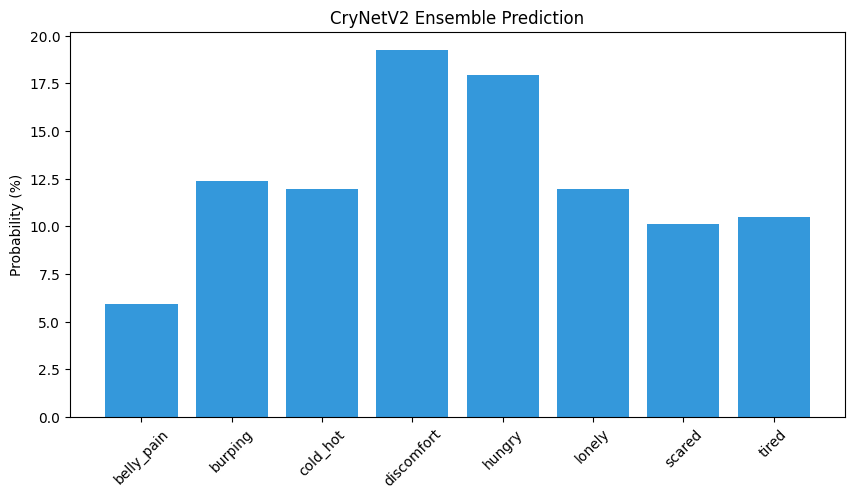

In [5]:
if audio_path:
    with torch.no_grad():
        cn_prob = F.softmax(crynet(mel_t), dim=1).numpy()[0]
        v2_prob = F.softmax(crynetv2(mel_t, dst_t), dim=1).numpy()[0]
    
    ml_prob = ml_ensemble.predict_proba(ml_feat.reshape(1, -1))[0]
    
    # Meta-Ensemble Weighting (ML: 20%, CryNet: 30%, CryNetV2: 50%)
    ensemble_prob = 0.20 * ml_prob + 0.30 * cn_prob + 0.50 * v2_prob
    
    pred_idx = np.argmax(ensemble_prob)
    print(f"Predicted Class: {CLASS_LABELS[pred_idx].upper()}")
    print(f"Confidence:      {ensemble_prob[pred_idx]*100:.2f}%")
    
    # Plot Probabilities
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(CLASS_LABELS, ensemble_prob * 100, color='#3498db')
    ax.set_ylabel('Probability (%)')
    ax.set_title('CryNetV2 Ensemble Prediction')
    plt.xticks(rotation=45)
    plt.show()